# Part 4 — Cluster Profiles & Business Interpretation

## 6. Cluster Profiles & Business Interpretation

In [9]:
profile = df.groupby('Cluster')[['Age','Income','Spending']].mean().round(1)
profile['Count']    = df['Cluster'].value_counts().sort_index()
profile['Female_%'] = df.groupby('Cluster')['Gender'].apply(
    lambda x: round((x == 'Female').mean() * 100, 1)
)

SEGMENT_NAMES = {
    0: 'Average Customers',
    1: 'High Income High Spenders',
    2: 'Low Income High Spenders',
    3: 'High Income Low Spenders',
    4: 'Low Income Low Spenders',
}
profile['Segment'] = profile.index.map(SEGMENT_NAMES)

print("Cluster Profiles:")
print(profile.to_string())

Cluster Profiles:
          Age  Income  Spending  Count  Female_%                    Segment
Cluster                                                                    
0        42.7    55.3      49.5     81      59.3          Average Customers
1        32.7    86.5      82.1     39      53.8  High Income High Spenders
2        25.3    25.7      79.4     22      59.1   Low Income High Spenders
3        41.1    88.2      17.1     35      45.7   High Income Low Spenders
4        45.2    26.3      20.9     23      60.9    Low Income Low Spenders


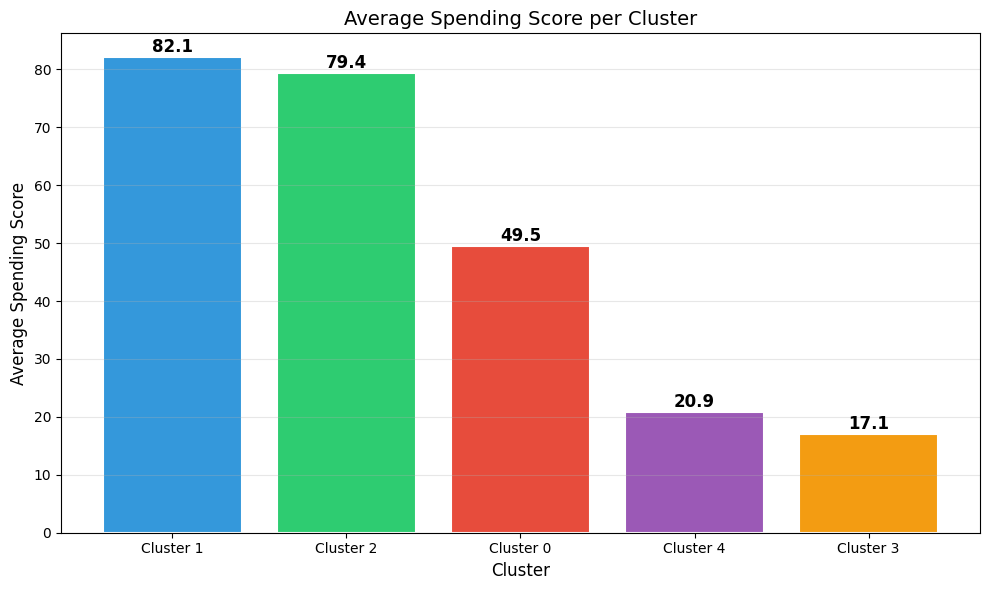

In [10]:
# Average spending per cluster (bonus requirement)
plt.figure(figsize=(10, 6))
avg = df.groupby('Cluster')['Spending'].mean().sort_values(ascending=False)
bars = plt.bar(
    [f'Cluster {i}' for i in avg.index],
    avg.values,
    color=[COLORS[i] for i in avg.index],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Average Spending Score', fontsize=12)
plt.title('Average Spending Score per Cluster', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Radar Chart — Cluster Profiles

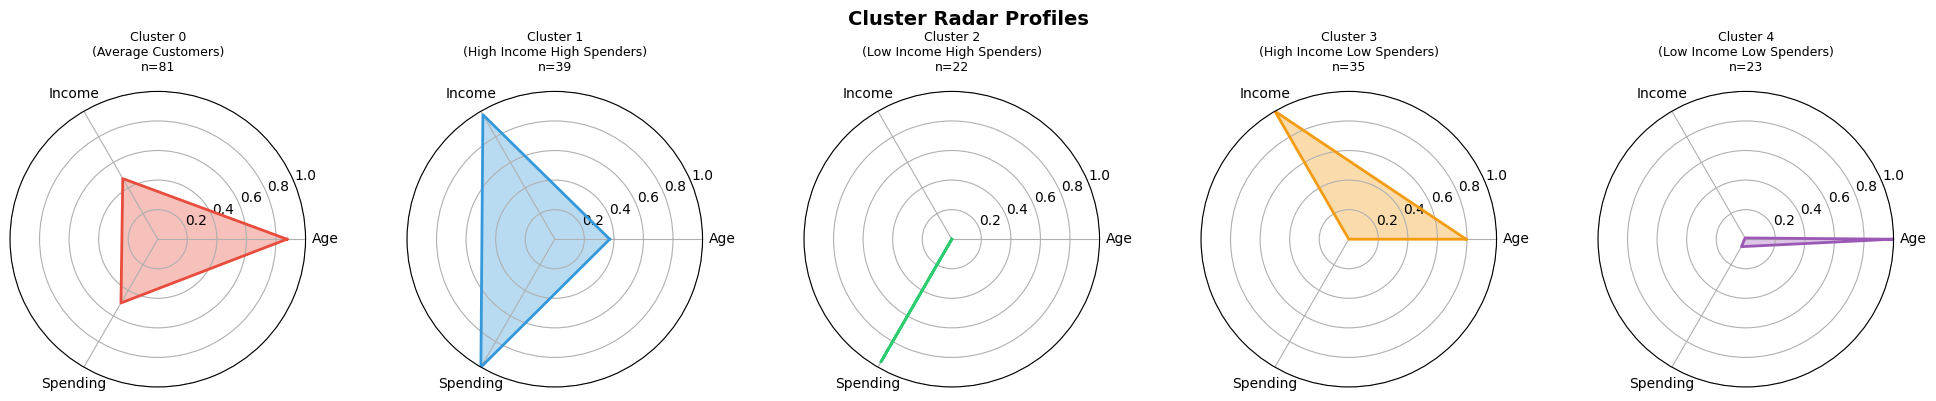

In [12]:
features  = ['Age', 'Income', 'Spending']
norm_prof = (profile[features] - profile[features].min()) /             (profile[features].max() - profile[features].min())
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, BEST_K, figsize=(4 * BEST_K, 4),
                          subplot_kw=dict(polar=True))

for i, ax in enumerate(axes):
    vals = norm_prof.iloc[i].tolist() + [norm_prof.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=COLORS[i], linewidth=2)
    ax.fill(angles, vals, color=COLORS[i], alpha=0.35)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.set_title(
        f"""Cluster {i}
({SEGMENT_NAMES[i]})
n={int(profile["Count"].iloc[i])}""",
        fontsize=9, pad=15
    )
    ax.set_ylim(0, 1)

plt.suptitle('Cluster Radar Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()